In [4]:

import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:128"
os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"

from pathlib import Path

DATASET_ROOT_EXPLICIT = ""
BASE_MODEL_EXPLICIT = ""


ALLOW_BASE_MODEL_DOWNLOAD = True
BASE_MODEL_REPO = "stable-diffusion-v1-5/stable-diffusion-v1-5"

EXPECTED_IMAGES = 206
TRIGGER_TOKEN = "wallpapx"

RESOLUTION = 512
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 1
NUM_REPEATS = 1
MAX_TRAIN_EPOCHS = 10

NETWORK_DIM = 32
NETWORK_ALPHA = 16
LEARNING_RATE = 1e-4
LR_SCHEDULER = "cosine"
MIN_SNR_GAMMA = 5.0

SAVE_EVERY_N_EPOCHS = 2
SEED = 42
LORA_TEST_WEIGHT = 0.85
RUN_SMOKE_TEST = True
RUN_CHECKPOINT_EVOLUTION = True

WORK_ROOT = Path("/kaggle/working/wallpaper_lora_project")
SD_SCRIPTS_DIR = Path("/kaggle/working/sd-scripts")
TRAIN_DIR = WORK_ROOT / "train_data"
SMOKE_DIR = WORK_ROOT / "smoke_data"
OUTPUT_DIR = WORK_ROOT / "output"
LOG_DIR = WORK_ROOT / "logs"
FULL_LOG_DIR = LOG_DIR / "full"
SMOKE_LOG_DIR = LOG_DIR / "smoke"
PREVIEW_DIR = WORK_ROOT / "previews"
EVAL_DIR = PREVIEW_DIR / "evaluation"

DATASET_CONFIG = WORK_ROOT / "dataset_config.toml"
SMOKE_CONFIG = WORK_ROOT / "smoke_dataset_config.toml"
MANIFEST_CSV = WORK_ROOT / "manifest.csv"

for p in [
    WORK_ROOT, TRAIN_DIR, SMOKE_DIR, OUTPUT_DIR, FULL_LOG_DIR,
    SMOKE_LOG_DIR, PREVIEW_DIR, EVAL_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

print("Work root:", WORK_ROOT)
print("Trigger token:", TRIGGER_TOKEN)


Work root: /kaggle/working/wallpaper_lora_project
Trigger token: wallpapx


In [5]:

import sys
import platform
import subprocess
import torch

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)

subprocess.run(["nvidia-smi"], check=False)

assert torch.cuda.is_available(), (
    "فعّلي GPU من Kaggle > Settings > Accelerator."
)

gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
major, minor = torch.cuda.get_device_capability(0)
current_arch = f"sm_{major}{minor}"
compiled_arches = torch.cuda.get_arch_list()

print("GPU:", gpu_name)
print(f"VRAM: {vram_gb:.1f} GB")
print("Compute capability:", current_arch)
print("Torch compiled architectures:", compiled_arches)

assert current_arch in compiled_arches, (
    f"نسخة PyTorch الحالية لا تحتوي دعم {current_arch}. "
    f"GPU الحالية: {gpu_name}. اختاري T4 من Kaggle أو استخدمي Runtime مختلفًا."
)

x = torch.randn(32, 32, device="cuda")
y = x @ x
torch.cuda.synchronize()
del x, y
torch.cuda.empty_cache()

print("CUDA execution test passed.")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
CUDA runtime: 12.8
Fri Jul 31 14:36:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             34W /   70W |     137MiB /  15360MiB |      0%      Defau

In [6]:

import shutil
import subprocess
import sys
from pathlib import Path

SD_SCRIPTS_TAG = "v0.10.6"
INSTALL_MARKER = Path("/kaggle/working/.sd_scripts_v0_10_6_installed")



REPO_TAG_FILE = SD_SCRIPTS_DIR / ".kaggle_pinned_tag"
repo_ready = (
    (SD_SCRIPTS_DIR / "train_network.py").is_file()
    and (SD_SCRIPTS_DIR / "requirements.txt").is_file()
    and REPO_TAG_FILE.is_file()
    and REPO_TAG_FILE.read_text(encoding="utf-8").strip() == SD_SCRIPTS_TAG
)

if not repo_ready:
    if SD_SCRIPTS_DIR.exists():
        shutil.rmtree(SD_SCRIPTS_DIR)

    print("Cloning sd-scripts...")
    clone = subprocess.run(
        [
            "git", "clone", "--depth", "1", "--branch", SD_SCRIPTS_TAG,
            "https://github.com/kohya-ss/sd-scripts.git",
            str(SD_SCRIPTS_DIR),
        ],
        text=True,
        capture_output=True,
    )
    if clone.returncode != 0:
        print(clone.stdout)
        print(clone.stderr)
        raise RuntimeError(
            "فشل تنزيل sd-scripts. فعّلي Internet من إعدادات Kaggle ثم أعيدي تشغيل الخلية."
        )
    REPO_TAG_FILE.write_text(SD_SCRIPTS_TAG, encoding="utf-8")

if not INSTALL_MARKER.exists():
    print("Installing official sd-scripts requirements in Kaggle Python...")

    install = subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet",
            "--no-cache-dir",
            "--upgrade-strategy", "only-if-needed",
            "-r", str(SD_SCRIPTS_DIR / "requirements.txt"),
        ],
        cwd=str(SD_SCRIPTS_DIR),
        text=True,
        capture_output=True,
    )

    if install.returncode != 0:
        print(install.stdout)
        print(install.stderr)
        raise RuntimeError("فشل تثبيت متطلبات sd-scripts.")

    peft_install = subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet", "--no-cache-dir",
            "peft==0.14.0",
        ],
        text=True,
        capture_output=True,
    )
    if peft_install.returncode != 0:
        print(peft_install.stdout)
        print(peft_install.stderr)
        raise RuntimeError("فشل تثبيت PEFT المستخدم لاختبار LoRA.")

else:
    print("Dependencies already installed in this Kaggle session.")

check_code = """
import torch, accelerate, transformers, diffusers, safetensors, bitsandbytes
print('torch        :', torch.__version__)
print('accelerate   :', accelerate.__version__)
print('transformers :', transformers.__version__)
print('diffusers    :', diffusers.__version__)
print('safetensors  :', safetensors.__version__)
print('bitsandbytes :', bitsandbytes.__version__)
"""
version_check = subprocess.run(
    [sys.executable, "-c", check_code],
    text=True,
    capture_output=True,
)
print(version_check.stdout)
if version_check.returncode != 0:
    print(version_check.stderr)
    INSTALL_MARKER.unlink(missing_ok=True)
    raise RuntimeError("فشل فحص مكتبات التدريب بعد التثبيت.")

INSTALL_MARKER.touch()
print("sd-scripts ready:", SD_SCRIPTS_DIR)


Cloning sd-scripts...
Installing official sd-scripts requirements in Kaggle Python...
torch        : 2.10.0+cu128
accelerate   : 1.6.0
transformers : 4.54.1
diffusers    : 0.32.1
safetensors  : 0.4.5
bitsandbytes : 0.50.0

sd-scripts ready: /kaggle/working/sd-scripts


In [7]:

import gc
import json
import math
import random
import re
import shutil
from pathlib import Path
from typing import Union

import numpy as np
import pandas as pd
from PIL import Image

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

def find_dataset_root() -> Path:
    if DATASET_ROOT_EXPLICIT:
        root = Path(DATASET_ROOT_EXPLICIT)
        assert root.exists(), f"Dataset root غير موجود: {root}"
        return root

    candidates = []
    for metadata_path in Path("/kaggle/input").rglob("metadata_clean.json"):
        root = metadata_path.parent
        if (root / "10_wallpapx").is_dir():
            candidates.append(root)

    candidates = sorted(set(candidates))
    assert candidates, (
        "لم أجد metadata_clean.json بجانب مجلد 10_wallpapx داخل /kaggle/input."
    )
    if len(candidates) > 1:
        print("Dataset candidates:")
        for candidate in candidates:
            print(" -", candidate)
        raise RuntimeError(
            "وجدت أكثر من داتاست مرشحة. حددي DATASET_ROOT_EXPLICIT في الخلية الأولى."
        )
    return candidates[0]

def find_base_model() -> Union[Path, str]:
    if BASE_MODEL_EXPLICIT:
        explicit = Path(BASE_MODEL_EXPLICIT)
        if explicit.exists():
            return explicit
        if "/" in BASE_MODEL_EXPLICIT:
            return BASE_MODEL_EXPLICIT
        raise FileNotFoundError(f"Base model غير موجود: {BASE_MODEL_EXPLICIT}")

    diffusers_dirs = []
    for model_index in Path("/kaggle/input").rglob("model_index.json"):
        parent = model_index.parent
        try:
            info = json.loads(model_index.read_text(encoding="utf-8"))
        except Exception:
            continue

        pipeline_class = str(info.get("_class_name", ""))
        is_sd_pipeline = pipeline_class == "StableDiffusionPipeline"
        has_required_parts = (
            (parent / "unet").is_dir()
            and (parent / "vae").is_dir()
            and (parent / "tokenizer").is_dir()
            and (parent / "text_encoder").is_dir()
        )
        if is_sd_pipeline and has_required_parts:
            diffusers_dirs.append(parent)

    diffusers_dirs = sorted(set(diffusers_dirs))
    if len(diffusers_dirs) == 1:
        return diffusers_dirs[0]
    if len(diffusers_dirs) > 1:
        preferred = [
            p for p in diffusers_dirs
            if any(token in str(p).lower() for token in [
                "stable-diffusion-v1-5", "sd15", "sd-v1-5"
            ])
        ]
        if len(preferred) == 1:
            return preferred[0]
        print("وجدت أكثر من Stable Diffusion Pipeline:")
        for p in diffusers_dirs:
            print(" -", p)
        raise RuntimeError(
            "حددي BASE_MODEL_EXPLICIT حتى لا يتم اختيار Base Model خاطئ."
        )

    checkpoints = []
    for path in Path("/kaggle/input").rglob("*.safetensors"):
        name = path.name.lower()
        is_sd15 = (
            "v1-5-pruned" in name
            or "sd15" in name
            or "sd-v1-5" in name
        )
        if is_sd15 and "lora" not in name:
            checkpoints.append(path)

    checkpoints = sorted(set(checkpoints))
    if len(checkpoints) == 1:
        return checkpoints[0]
    if len(checkpoints) > 1:
        ema_only = [p for p in checkpoints if "emaonly" in p.name.lower()]
        if len(ema_only) == 1:
            return ema_only[0]
        print("وجدت أكثر من SD 1.5 checkpoint:")
        for p in checkpoints:
            print(" -", p)
        raise RuntimeError(
            "حددي BASE_MODEL_EXPLICIT حتى لا يتم اختيار Checkpoint خاطئ."
        )

    if ALLOW_BASE_MODEL_DOWNLOAD:
        return BASE_MODEL_REPO

    raise FileNotFoundError(
        "لم أجد SD 1.5 محليًا. ارفعيه كـKaggle Dataset أو فعّلي التنزيل."
    )

DATASET_ROOT = find_dataset_root()
SOURCE_DIR = DATASET_ROOT / "10_wallpapx"
METADATA_PATH = DATASET_ROOT / "metadata_clean.json"
BASE_MODEL = find_base_model()

print("DATASET_ROOT:", DATASET_ROOT)
print("SOURCE_DIR  :", SOURCE_DIR)
print("METADATA    :", METADATA_PATH)
print("BASE_MODEL  :", BASE_MODEL)

assert SOURCE_DIR.is_dir()
assert METADATA_PATH.is_file()

if isinstance(BASE_MODEL, Path) and BASE_MODEL.is_file():
    print(f"Base checkpoint size: {BASE_MODEL.stat().st_size / 1024**3:.2f} GB")
    assert BASE_MODEL.stat().st_size > 3 * 1024**3, (
        "ملف SD 1.5 المحلي يبدو ناقصًا."
    )


DATASET_ROOT: /kaggle/input/datasets/ayasahlol/wallpaper-data/wallpaper_lora_clean_kaggle_dataset
SOURCE_DIR  : /kaggle/input/datasets/ayasahlol/wallpaper-data/wallpaper_lora_clean_kaggle_dataset/10_wallpapx
METADATA    : /kaggle/input/datasets/ayasahlol/wallpaper-data/wallpaper_lora_clean_kaggle_dataset/metadata_clean.json
BASE_MODEL  : stable-diffusion-v1-5/stable-diffusion-v1-5


In [8]:

raw_metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

if isinstance(raw_metadata, dict) and isinstance(raw_metadata.get("images"), list):
    records = raw_metadata["images"]
elif isinstance(raw_metadata, list):
    records = raw_metadata
else:
    raise ValueError("بنية metadata_clean.json غير مدعومة.")

records = [
    item for item in records
    if item.get("training_ready", True) is not False
]

source_images = sorted(
    p for p in SOURCE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)
source_txt = sorted(SOURCE_DIR.glob("*.txt"))

assert len(records) == EXPECTED_IMAGES, (
    f"عدد سجلات JSON يجب أن يكون {EXPECTED_IMAGES}، الموجود {len(records)}."
)
assert len(source_images) == EXPECTED_IMAGES, (
    f"عدد الصور يجب أن يكون {EXPECTED_IMAGES}، الموجود {len(source_images)}."
)
assert len(source_txt) == EXPECTED_IMAGES, (
    f"عدد ملفات TXT يجب أن يكون {EXPECTED_IMAGES}، الموجود {len(source_txt)}."
)

images_by_name = {p.name.lower(): p for p in source_images}
txt_by_stem = {p.stem.lower(): p for p in source_txt}

rows = []
errors = []

for item in records:
    file_name = str(item.get("file_name", "")).strip()
    caption_json = " ".join(str(item.get("text", "")).split())

    image_path = images_by_name.get(Path(file_name).name.lower())
    if image_path is None:
        errors.append((file_name, "missing image"))
        continue

    txt_path = txt_by_stem.get(image_path.stem.lower())
    if txt_path is None:
        errors.append((file_name, "missing txt"))
        continue

    caption_txt = " ".join(txt_path.read_text(encoding="utf-8").split())

    if not caption_txt:
        errors.append((file_name, "empty caption"))
    if caption_txt != caption_json:
        errors.append((file_name, "TXT != metadata text"))
    if not caption_txt.lower().startswith(TRIGGER_TOKEN.lower()):
        errors.append((file_name, "caption does not start with trigger"))
    if re.search(r"\bfloor\b", caption_txt.lower()):
        errors.append((file_name, "caption contains floor"))

    try:
        with Image.open(image_path) as image:
            image_format = image.format or image_path.suffix.lstrip(".")
            width, height = image.size
            image.load()
            image.convert("RGB")
    except Exception as exc:
        errors.append((file_name, f"invalid image: {exc!r}"))
        continue

    rows.append({
        "file_name": image_path.name,
        "image_path": str(image_path),
        "txt_path": str(txt_path),
        "caption": caption_txt,
        "width": width,
        "height": height,
        "min_side": min(width, height),
        "wallpaper_type": item.get("wallpaper_type", ""),
        "pattern_family": item.get("pattern_family", ""),
    })

assert not errors, f"وجدت أخطاء في الداتاست: {errors[:20]}"
assert len(rows) == EXPECTED_IMAGES

manifest = pd.DataFrame(rows)
assert manifest["caption"].nunique() > EXPECTED_IMAGES * 0.5
assert manifest["min_side"].min() >= RESOLUTION, (
    "توجد صورة أصغر من دقة التدريب 512."
)

if TRAIN_DIR.exists():
    shutil.rmtree(TRAIN_DIR)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

for row in manifest.itertuples(index=False):
    shutil.copy2(row.image_path, TRAIN_DIR / Path(row.image_path).name)
    shutil.copy2(row.txt_path, TRAIN_DIR / Path(row.txt_path).name)

if SMOKE_DIR.exists():
    shutil.rmtree(SMOKE_DIR)
SMOKE_DIR.mkdir(parents=True, exist_ok=True)

for row in manifest.head(4).itertuples(index=False):
    shutil.copy2(row.image_path, SMOKE_DIR / Path(row.image_path).name)
    shutil.copy2(row.txt_path, SMOKE_DIR / Path(row.txt_path).name)

manifest.to_csv(MANIFEST_CSV, index=False)

summary = pd.DataFrame([
    {"Field": "Images", "Value": len(manifest)},
    {"Field": "Unique captions", "Value": manifest["caption"].nunique()},
    {"Field": "Minimum image side", "Value": int(manifest["min_side"].min())},
    {"Field": "Median image side", "Value": int(manifest["min_side"].median())},
    {"Field": "Resolution", "Value": RESOLUTION},
    {"Field": "Trigger token", "Value": TRIGGER_TOKEN},
])
display(summary)

print("Training copy:", TRAIN_DIR)
print("Manifest:", MANIFEST_CSV)
print("Dataset integrity check passed.")


,Field,Value
0,Images,206
1,Unique captions,206
2,Minimum image side,523
3,Median image side,736
4,Resolution,512
5,Trigger token,wallpapx


Training copy: /kaggle/working/wallpaper_lora_project/train_data
Manifest: /kaggle/working/wallpaper_lora_project/manifest.csv
Dataset integrity check passed.


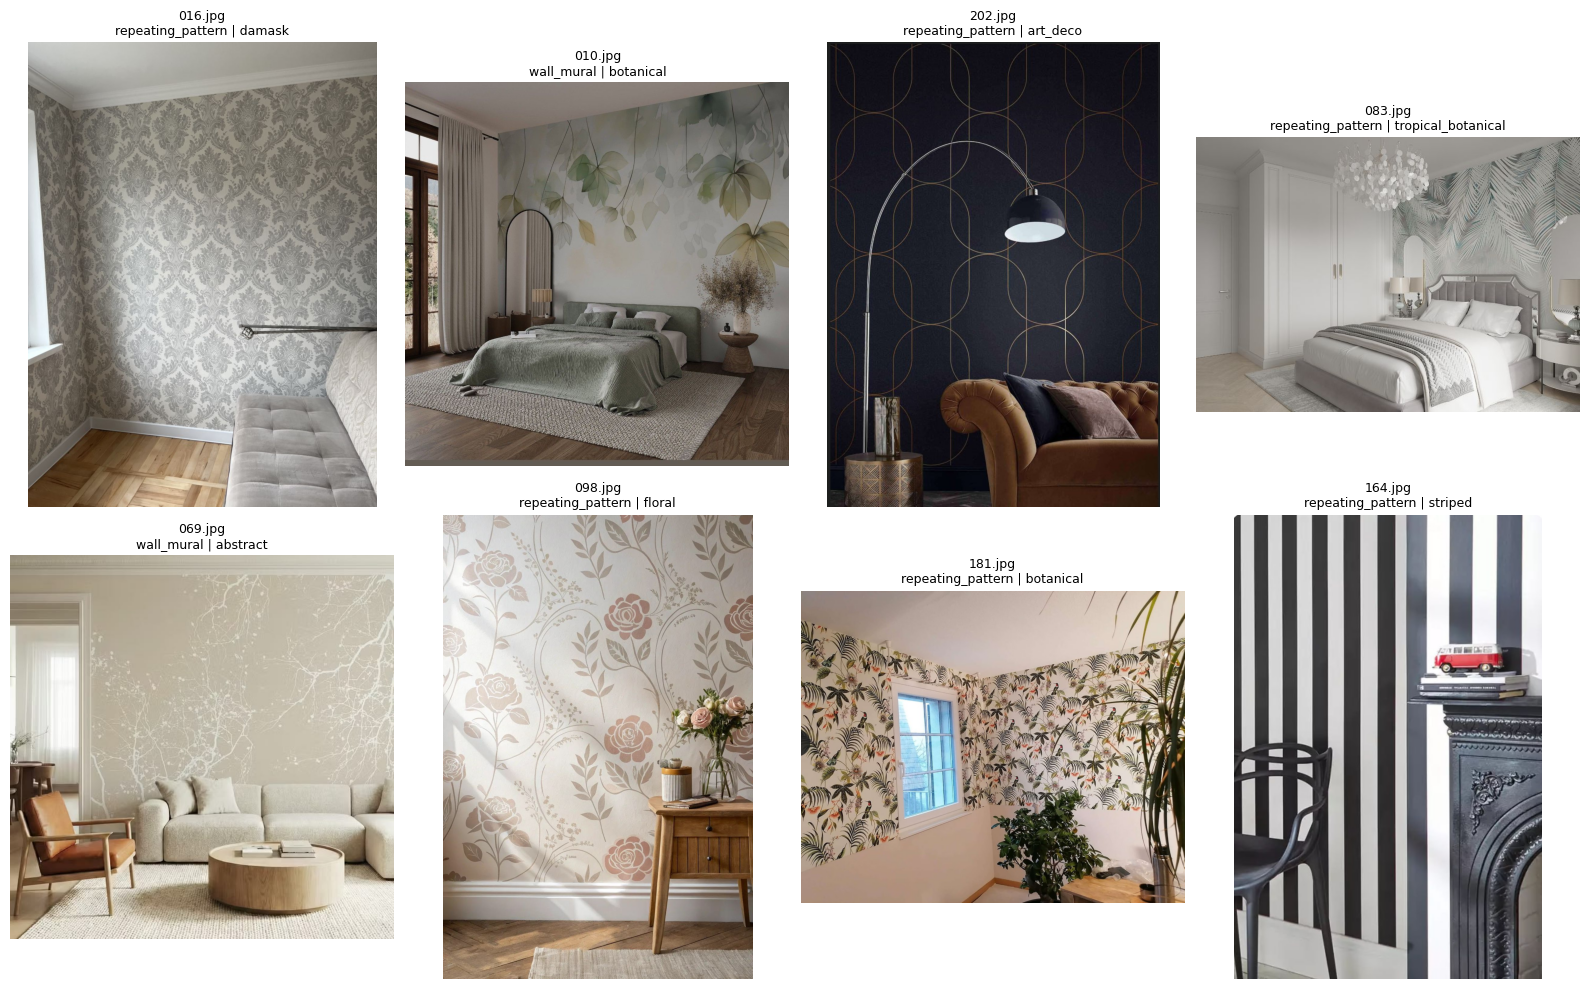

,file_name,wallpaper_type,pattern_family,caption
0,016.jpg,repeating_pattern,damask,"wallpapx, photorealistic bedroom interior, ful..."
1,010.jpg,wall_mural,botanical,"wallpapx, photorealistic bedroom interior, hea..."
2,202.jpg,repeating_pattern,art_deco,"wallpapx, photorealistic living room interior,..."
3,083.jpg,repeating_pattern,tropical_botanical,"wallpapx, photorealistic bedroom interior, hea..."
4,069.jpg,wall_mural,abstract,"wallpapx, photorealistic living room interior,..."
5,098.jpg,repeating_pattern,floral,"wallpapx, photorealistic living room interior,..."
6,181.jpg,repeating_pattern,botanical,"wallpapx, photorealistic bedroom interior, ful..."
7,164.jpg,repeating_pattern,striped,"wallpapx, photorealistic living room interior,..."


Saved: /kaggle/working/wallpaper_lora_project/previews/dataset_samples.png


In [9]:

import matplotlib.pyplot as plt

sample_rows = manifest.sample(
    n=min(8, len(manifest)),
    random_state=SEED,
).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, row in zip(axes, sample_rows.itertuples(index=False)):
    image = Image.open(row.image_path).convert("RGB")
    ax.imshow(image)
    ax.set_title(
        f"{row.file_name}\n{row.wallpaper_type} | {row.pattern_family}",
        fontsize=9,
    )
    ax.axis("off")

plt.tight_layout()
dataset_preview_path = PREVIEW_DIR / "dataset_samples.png"
plt.savefig(dataset_preview_path, dpi=160, bbox_inches="tight")
plt.show()

display(
    sample_rows[["file_name", "wallpaper_type", "pattern_family", "caption"]]
)
print("Saved:", dataset_preview_path)


In [10]:

dataset_toml = f"""
[general]
caption_extension = ".txt"
shuffle_caption = false
keep_tokens = 1

[[datasets]]
resolution = {RESOLUTION}
batch_size = {BATCH_SIZE}
enable_bucket = true
bucket_no_upscale = true
bucket_reso_steps = 64
min_bucket_reso = 256
max_bucket_reso = 1024

  [[datasets.subsets]]
  image_dir = "{TRAIN_DIR}"
  num_repeats = {NUM_REPEATS}
""".strip() + "\n"

smoke_toml = f"""
[general]
caption_extension = ".txt"
shuffle_caption = false
keep_tokens = 1

[[datasets]]
resolution = {RESOLUTION}
batch_size = 1
enable_bucket = true
bucket_no_upscale = true
bucket_reso_steps = 64
min_bucket_reso = 256
max_bucket_reso = 1024

  [[datasets.subsets]]
  image_dir = "{SMOKE_DIR}"
  num_repeats = 1
""".strip() + "\n"

DATASET_CONFIG.write_text(dataset_toml, encoding="utf-8")
SMOKE_CONFIG.write_text(smoke_toml, encoding="utf-8")

steps_per_epoch = math.ceil(
    len(manifest) * NUM_REPEATS
    / (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
)
estimated_steps = steps_per_epoch * MAX_TRAIN_EPOCHS

training_plan = pd.DataFrame([
    {"Parameter": "Images", "Value": len(manifest)},
    {"Parameter": "Repeats", "Value": NUM_REPEATS},
    {"Parameter": "Epochs", "Value": MAX_TRAIN_EPOCHS},
    {"Parameter": "Steps per epoch", "Value": steps_per_epoch},
    {"Parameter": "Estimated optimizer steps", "Value": estimated_steps},
    {"Parameter": "LoRA rank / alpha", "Value": f"{NETWORK_DIM} / {NETWORK_ALPHA}"},
    {"Parameter": "Learning rate", "Value": LEARNING_RATE},
])
display(training_plan)

print(DATASET_CONFIG.read_text(encoding="utf-8"))
assert 1800 <= estimated_steps <= 2600, (
    f"عدد الخطوات غير المتوقع: {estimated_steps}"
)


,Parameter,Value
0,Images,206
1,Repeats,1
2,Epochs,10
3,Steps per epoch,206
4,Estimated optimizer steps,2060
5,LoRA rank / alpha,32 / 16
6,Learning rate,0.0001


[general]
caption_extension = ".txt"
shuffle_caption = false
keep_tokens = 1

[[datasets]]
resolution = 512
batch_size = 1
enable_bucket = true
bucket_no_upscale = true
bucket_reso_steps = 64
min_bucket_reso = 256
max_bucket_reso = 1024

  [[datasets.subsets]]
  image_dir = "/kaggle/working/wallpaper_lora_project/train_data"
  num_repeats = 1



In [11]:

import shlex

def build_training_command(
    *,
    dataset_config: Path,
    output_name: str,
    log_dir: Path,
    max_epochs: int | None = None,
    max_steps: int | None = None,
    cache_latents: bool = True,
):
    command = [
        sys.executable,
        "-u",
        str(SD_SCRIPTS_DIR / "train_network.py"),
        f"--pretrained_model_name_or_path={BASE_MODEL}",
        f"--dataset_config={dataset_config}",
        f"--output_dir={OUTPUT_DIR}",
        f"--output_name={output_name}",
        "--save_model_as=safetensors",
        "--save_precision=fp16",
        f"--resolution={RESOLUTION},{RESOLUTION}",
        f"--train_batch_size={BATCH_SIZE}",
        f"--gradient_accumulation_steps={GRADIENT_ACCUMULATION_STEPS}",
        f"--learning_rate={LEARNING_RATE}",
        f"--unet_lr={LEARNING_RATE}",
        "--network_module=networks.lora",
        f"--network_dim={NETWORK_DIM}",
        f"--network_alpha={NETWORK_ALPHA}",
        "--network_train_unet_only",
        "--optimizer_type=AdamW8bit",
        f"--lr_scheduler={LR_SCHEDULER}",
        "--lr_warmup_ratio=0.05",
        "--mixed_precision=fp16",
        f"--logging_dir={log_dir}",
        "--log_with=tensorboard",
        "--gradient_checkpointing",
        "--sdpa",
        "--max_data_loader_n_workers=0",
        "--vae_batch_size=1",
        f"--min_snr_gamma={MIN_SNR_GAMMA}",
        "--max_grad_norm=1.0",
        "--scale_weight_norms=1.0",
        f"--seed={SEED}",
    ]

    if max_epochs is not None:
        command += [
            f"--max_train_epochs={max_epochs}",
            f"--save_every_n_epochs={SAVE_EVERY_N_EPOCHS}",
            "--save_last_n_epochs=5",
        ]

    if max_steps is not None:
        command += [
            f"--max_train_steps={max_steps}",
            f"--save_every_n_steps={max_steps}",
            "--save_last_n_steps=1",
        ]

    if cache_latents:
        command += [
            "--cache_latents",
            "--cache_latents_to_disk",
        ]

    return command

SMOKE_COMMAND = build_training_command(
    dataset_config=SMOKE_CONFIG,
    output_name="wallpaper_lora_smoke",
    log_dir=SMOKE_LOG_DIR,
    max_steps=2,
    cache_latents=False,
)

FULL_COMMAND = build_training_command(
    dataset_config=DATASET_CONFIG,
    output_name="wallpaper_lora",
    log_dir=FULL_LOG_DIR,
    max_epochs=MAX_TRAIN_EPOCHS,
    cache_latents=True,
)

def printable_command(command):
    return " \\\n  ".join(shlex.quote(str(value)) for value in command)

print("SMOKE COMMAND:\n")
print(printable_command(SMOKE_COMMAND))
print("\nFULL COMMAND:\n")
print(printable_command(FULL_COMMAND))


SMOKE COMMAND:

/usr/bin/python3 \
  -u \
  /kaggle/working/sd-scripts/train_network.py \
  --pretrained_model_name_or_path=stable-diffusion-v1-5/stable-diffusion-v1-5 \
  --dataset_config=/kaggle/working/wallpaper_lora_project/smoke_dataset_config.toml \
  --output_dir=/kaggle/working/wallpaper_lora_project/output \
  --output_name=wallpaper_lora_smoke \
  --save_model_as=safetensors \
  --save_precision=fp16 \
  --resolution=512,512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=0.0001 \
  --unet_lr=0.0001 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --network_train_unet_only \
  --optimizer_type=AdamW8bit \
  --lr_scheduler=cosine \
  --lr_warmup_ratio=0.05 \
  --mixed_precision=fp16 \
  --logging_dir=/kaggle/working/wallpaper_lora_project/logs/smoke \
  --log_with=tensorboard \
  --gradient_checkpointing \
  --sdpa \
  --max_data_loader_n_workers=0 \
  --vae_batch_size=1 \
  --min_snr_gamma=5.0 \
  --max_grad_n

In [13]:

import subprocess
import shlex

cleanup_memory()


def replace_warmup_argument(command, warmup_steps):
    """
    يحذف أي صيغة قديمة من:
        --lr_warmup_ratio
        --lr_warmup_steps

    ثم يضيف:
        --lr_warmup_steps=<value>
    """
    command = list(command)
    fixed_command = []

    skip_next = False

    for arg in command:
        if skip_next:
            skip_next = False
            continue

        arg_text = str(arg)

        
        if arg_text.startswith("--lr_warmup_ratio="):
            continue

        if arg_text.startswith("--lr_warmup_steps="):
            continue

       
        if arg_text in {
            "--lr_warmup_ratio",
            "--lr_warmup_steps",
        }:
            skip_next = True
            continue

        fixed_command.append(arg)

    fixed_command.append(
        f"--lr_warmup_steps={max(0, int(warmup_steps))}"
    )

    return fixed_command


SMOKE_COMMAND = replace_warmup_argument(
    SMOKE_COMMAND,
    warmup_steps=0,
)

if "FULL_COMMAND" in globals():
    if "estimated_steps" in globals():
        full_warmup_steps = max(
            1,
            int(round(estimated_steps * 0.05))
        )
    else:
        full_warmup_steps = 103

    FULL_COMMAND = replace_warmup_argument(
        FULL_COMMAND,
        warmup_steps=full_warmup_steps,
    )

    print(
        "Full training warmup steps:",
        full_warmup_steps,
    )


print("=" * 80)
print("SMOKE TEST COMMAND")
print("=" * 80)
print(
    " \\\n  ".join(
        shlex.quote(str(arg))
        for arg in SMOKE_COMMAND
    )
)


if RUN_SMOKE_TEST:
    smoke_log_path = WORK_ROOT / "train_smoke.log"

    if smoke_log_path.exists():
        smoke_log_path.unlink()

    with smoke_log_path.open(
        "w",
        encoding="utf-8",
    ) as log_file:

        smoke_result = subprocess.run(
            SMOKE_COMMAND,
            cwd=str(SD_SCRIPTS_DIR),
            stdout=log_file,
            stderr=subprocess.STDOUT,
            text=True,
        )

    smoke_tail = smoke_log_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()[-100:]

    print("\n" + "=" * 80)
    print("SMOKE TEST LOG")
    print("=" * 80)
    print("\n".join(smoke_tail))

    if smoke_result.returncode != 0:
        raise RuntimeError(
            "Smoke Test فشل.\n"
            f"Exit code: {smoke_result.returncode}\n"
            f"Log path: {smoke_log_path}"
        )

    for path in OUTPUT_DIR.glob(
        "wallpaper_lora_smoke*.safetensors"
    ):
        path.unlink()

    cleanup_memory()

    print("\n" + "=" * 80)
    print("Smoke Test passed.")
    print("التدريب الكامل جاهز للبدء.")
    print("=" * 80)

else:
    print("Smoke Test skipped.")

Full training warmup steps: 103
SMOKE TEST COMMAND
/usr/bin/python3 \
  -u \
  /kaggle/working/sd-scripts/train_network.py \
  --pretrained_model_name_or_path=stable-diffusion-v1-5/stable-diffusion-v1-5 \
  --dataset_config=/kaggle/working/wallpaper_lora_project/smoke_dataset_config.toml \
  --output_dir=/kaggle/working/wallpaper_lora_project/output \
  --output_name=wallpaper_lora_smoke \
  --save_model_as=safetensors \
  --save_precision=fp16 \
  --resolution=512,512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=0.0001 \
  --unet_lr=0.0001 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --network_train_unet_only \
  --optimizer_type=AdamW8bit \
  --lr_scheduler=cosine \
  --mixed_precision=fp16 \
  --logging_dir=/kaggle/working/wallpaper_lora_project/logs/smoke \
  --log_with=tensorboard \
  --gradient_checkpointing \
  --sdpa \
  --max_data_loader_n_workers=0 \
  --vae_batch_size=1 \
  --min_snr_gamma=5.0 \
  --ma

In [15]:

import os
import pty
import time
import shlex
import select
import subprocess
import pandas as pd

cleanup_memory()

full_log_path = WORK_ROOT / "train_full.log"

def fix_training_command(command):
    fixed = []
    skip_next = False

    for arg in list(command):
        if skip_next:
            skip_next = False
            continue

        arg = str(arg)

        if arg.startswith("--lr_warmup_ratio="):
            continue

        if arg == "--lr_warmup_ratio":
            skip_next = True
            continue

        if arg.startswith("--lr_warmup_steps="):
            continue

        if arg == "--lr_warmup_steps":
            skip_next = True
            continue

        fixed.append(arg)

    fixed.append("--lr_warmup_steps=103")

    return fixed


FULL_COMMAND = fix_training_command(FULL_COMMAND)

print("=" * 100)
print("WALLPAPER LoRA FULL TRAINING")
print("=" * 100)
print("Output directory :", OUTPUT_DIR)
print("Log file         :", full_log_path)
print("Warmup steps     : 103")
print("Expected steps   : approximately 2060")
print()

print("Training command:")
print(
    " \\\n  ".join(
        shlex.quote(str(arg))
        for arg in FULL_COMMAND
    )
)
print()
print("=" * 100)
print("LIVE TRAINING OUTPUT")
print("=" * 100)

if full_log_path.exists():
    full_log_path.unlink()

training_env = os.environ.copy()
training_env["PYTHONUNBUFFERED"] = "1"
training_env["PYTHONIOENCODING"] = "utf-8"
training_env["TOKENIZERS_PARALLELISM"] = "false"

start_time = time.time()

master_fd, slave_fd = pty.openpty()

process = subprocess.Popen(
    FULL_COMMAND,
    cwd=str(SD_SCRIPTS_DIR),
    stdin=subprocess.DEVNULL,
    stdout=slave_fd,
    stderr=slave_fd,
    env=training_env,
    close_fds=True,
)

os.close(slave_fd)

captured_output = ""

try:
    with full_log_path.open(
        "w",
        encoding="utf-8",
        buffering=1,
    ) as log_file:

        while True:
            ready, _, _ = select.select(
                [master_fd],
                [],
                [],
                0.2,
            )

            if master_fd in ready:
                try:
                    data = os.read(
                        master_fd,
                        4096,
                    )
                except OSError:
                    data = b""

                if data:
                    text = data.decode(
                        "utf-8",
                        errors="replace",
                    )

                    print(
                        text,
                        end="",
                        flush=True,
                    )

                    normalized_text = text.replace(
                        "\r",
                        "\n",
                    )

                    log_file.write(normalized_text)
                    log_file.flush()

                    captured_output += normalized_text

                    if len(captured_output) > 200_000:
                        captured_output = captured_output[-200_000:]

            return_code = process.poll()

            if return_code is not None:
                
                while True:
                    try:
                        data = os.read(
                            master_fd,
                            4096,
                        )
                    except OSError:
                        break

                    if not data:
                        break

                    text = data.decode(
                        "utf-8",
                        errors="replace",
                    )

                    print(
                        text,
                        end="",
                        flush=True,
                    )

                    log_file.write(
                        text.replace("\r", "\n")
                    )
                    log_file.flush()

                break

except KeyboardInterrupt:
    print("\n\nتم طلب إيقاف التدريب.")

    process.terminate()

    try:
        process.wait(timeout=15)
    except subprocess.TimeoutExpired:
        process.kill()
        process.wait()

    raise KeyboardInterrupt(
        "تم إيقاف التدريب يدويًا."
    )

finally:
    try:
        os.close(master_fd)
    except OSError:
        pass

elapsed_minutes = (
    time.time() - start_time
) / 60

print()
print("=" * 100)
print("TRAINING PROCESS FINISHED")
print("=" * 100)
print("Exit code   :", return_code)
print(
    "Elapsed time:",
    f"{elapsed_minutes:.2f} minutes",
)


if return_code != 0:
    log_lines = full_log_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    print()
    print("=" * 100)
    print("LAST 150 LOG LINES")
    print("=" * 100)
    print("\n".join(log_lines[-150:]))

    raise RuntimeError(
        "فشل التدريب الكامل.\n"
        f"Exit code: {return_code}\n"
        f"Log: {full_log_path}"
    )


lora_files = sorted(
    OUTPUT_DIR.glob(
        "wallpaper_lora*.safetensors"
    ),
    key=lambda path: path.stat().st_mtime,
)

assert lora_files, (
    "انتهى التدريب دون إنشاء ملف LoRA."
)

checkpoint_table = pd.DataFrame([
    {
        "Checkpoint": path.name,
        "Size MB": round(
            path.stat().st_size / 1024**2,
            2,
        ),
        "Modified": time.strftime(
            "%Y-%m-%d %H:%M:%S",
            time.localtime(
                path.stat().st_mtime
            ),
        ),
    }
    for path in lora_files
])

display(checkpoint_table)

cleanup_memory()

print()
print("=" * 100)
print("TRAINING COMPLETED SUCCESSFULLY")
print("=" * 100)
print("Output directory:", OUTPUT_DIR)
print("Log file:", full_log_path)
print("LoRA files:", len(lora_files))

for path in lora_files:
    print(" -", path.name)

WALLPAPER LoRA FULL TRAINING
Output directory : /kaggle/working/wallpaper_lora_project/output
Log file         : /kaggle/working/wallpaper_lora_project/train_full.log
Warmup steps     : 103
Expected steps   : approximately 2060

Training command:
/usr/bin/python3 \
  -u \
  /kaggle/working/sd-scripts/train_network.py \
  --pretrained_model_name_or_path=stable-diffusion-v1-5/stable-diffusion-v1-5 \
  --dataset_config=/kaggle/working/wallpaper_lora_project/dataset_config.toml \
  --output_dir=/kaggle/working/wallpaper_lora_project/output \
  --output_name=wallpaper_lora \
  --save_model_as=safetensors \
  --save_precision=fp16 \
  --resolution=512,512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=0.0001 \
  --unet_lr=0.0001 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --network_train_unet_only \
  --optimizer_type=AdamW8bit \
  --lr_scheduler=cosine \
  --mixed_precision=fp16 \
  --logging_dir=/kaggle/working/wallpa

,Checkpoint,Size MB,Modified
0,wallpaper_lora-000002.safetensors,26.03,2026-07-31 15:06:54
1,wallpaper_lora-000004.safetensors,26.03,2026-07-31 15:10:29
2,wallpaper_lora-000006.safetensors,26.03,2026-07-31 15:14:05
3,wallpaper_lora-000008.safetensors,26.03,2026-07-31 15:17:41
4,wallpaper_lora.safetensors,26.03,2026-07-31 15:21:17



TRAINING COMPLETED SUCCESSFULLY
Output directory: /kaggle/working/wallpaper_lora_project/output
Log file: /kaggle/working/wallpaper_lora_project/train_full.log
LoRA files: 5
 - wallpaper_lora-000002.safetensors
 - wallpaper_lora-000004.safetensors
 - wallpaper_lora-000006.safetensors
 - wallpaper_lora-000008.safetensors
 - wallpaper_lora.safetensors


TensorBoard event files found:
 - /kaggle/working/wallpaper_lora_project/logs/full/20260731144529/network_train/events.out.tfevents.1785509237.f3202e03c002.278.0
 - /kaggle/working/wallpaper_lora_project/logs/full/20260731150304/network_train/events.out.tfevents.1785510194.f3202e03c002.315.0
 - /kaggle/working/wallpaper_lora_project/logs/smoke/20260731144418/network_train/events.out.tfevents.1785509085.f3202e03c002.223.0

Selected full-training event:
/kaggle/working/wallpaper_lora_project/logs/full/20260731150304/network_train/events.out.tfevents.1785510194.f3202e03c002.315.0
Logged points: 2060
Maximum step: 2060


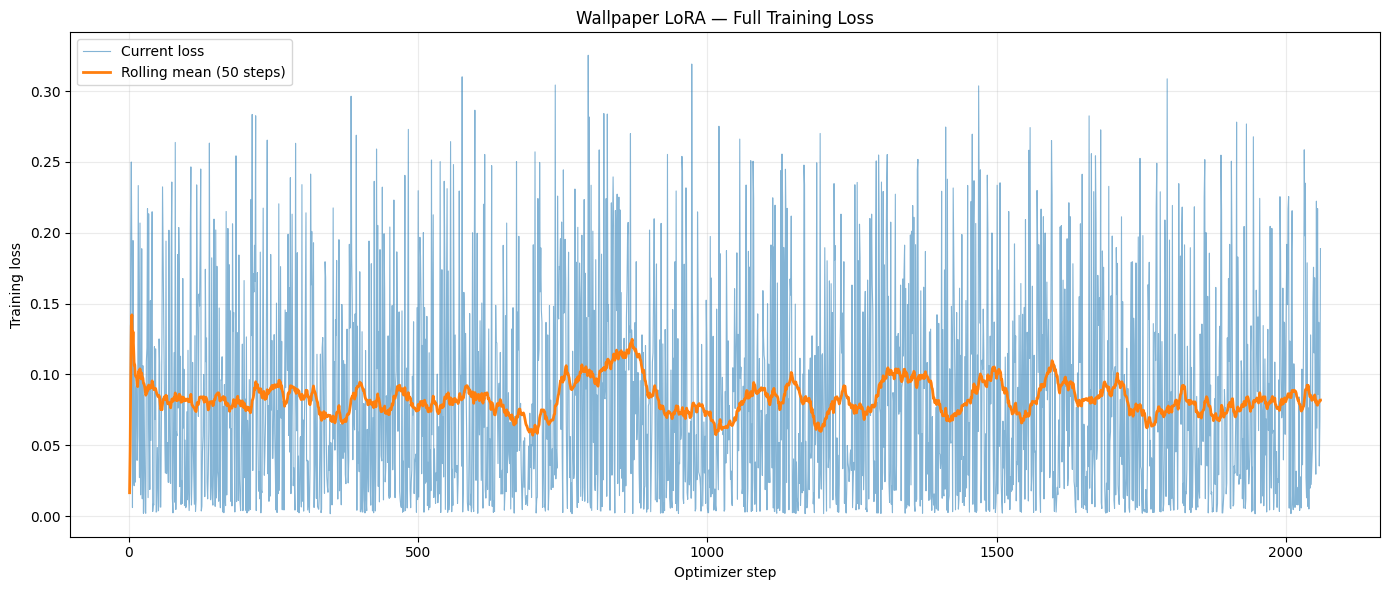

,Metric,Value
0,First current loss,0.016487
1,Final current loss,0.188819
2,Minimum rolling loss,0.016487
3,Final rolling loss,0.081875
4,Logged steps,2060.000000
5,Maximum optimizer step,2060.000000


Saved: /kaggle/working/wallpaper_lora_project/previews/training_loss_corrected.png


In [18]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tensorboard.backend.event_processing.event_accumulator import (
    EventAccumulator
)

event_files = sorted(
    LOG_DIR.rglob("events.out.tfevents*")
)

assert event_files, (
    f"لم يتم العثور على TensorBoard events داخل: {LOG_DIR}"
)

print("TensorBoard event files found:")
for event_file in event_files:
    print(" -", event_file)


event_candidates = []

for event_file in event_files:
    try:
        accumulator = EventAccumulator(
            str(event_file),
            size_guidance={"scalars": 0},
        )
        accumulator.Reload()

        scalar_tags = accumulator.Tags().get(
            "scalars",
            [],
        )

        # نستخدم Current Loss بشكل صريح
        if "loss/current" not in scalar_tags:
            continue

        events = accumulator.Scalars(
            "loss/current"
        )

        if not events:
            continue

        frame = pd.DataFrame({
            "step": [
                int(event.step)
                for event in events
            ],
            "loss": [
                float(event.value)
                for event in events
            ],
        })

        event_candidates.append({
            "event_file": event_file,
            "frame": frame,
            "event_count": len(frame),
            "max_step": int(frame["step"].max()),
        })

    except Exception as error:
        print(
            "Skipped:",
            event_file,
            repr(error),
        )


assert event_candidates, (
    "لم أجد loss/current داخل TensorBoard events."
)

selected = max(
    event_candidates,
    key=lambda item: (
        item["event_count"],
        item["max_step"],
    ),
)

loss_df = selected["frame"].copy()

loss_df = (
    loss_df
    .sort_values("step")
    .drop_duplicates(
        subset="step",
        keep="last",
    )
    .reset_index(drop=True)
)

loss_df = loss_df[
    loss_df["step"] >= 0
].copy()

ROLLING_WINDOW = 50

loss_df["rolling_loss"] = (
    loss_df["loss"]
    .rolling(
        window=ROLLING_WINDOW,
        min_periods=1,
    )
    .mean()
)

print()
print("Selected full-training event:")
print(selected["event_file"])
print("Logged points:", len(loss_df))
print("Maximum step:", loss_df["step"].max())

assert len(loss_df) >= 2000, (
    f"عدد الخطوات المقروء منخفض: {len(loss_df)}"
)



plt.figure(figsize=(14, 6))

plt.plot(
    loss_df["step"],
    loss_df["loss"],
    linewidth=0.8,
    alpha=0.55,
    label="Current loss",
)

plt.plot(
    loss_df["step"],
    loss_df["rolling_loss"],
    linewidth=2,
    label=f"Rolling mean ({ROLLING_WINDOW} steps)",
)

plt.xlabel("Optimizer step")
plt.ylabel("Training loss")
plt.title("Wallpaper LoRA — Full Training Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

LOSS_PLOT_PATH = (
    PREVIEW_DIR /
    "training_loss_corrected.png"
)

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


summary_df = pd.DataFrame([
    {
        "Metric": "First current loss",
        "Value": round(
            float(loss_df.iloc[0]["loss"]),
            6,
        ),
    },
    {
        "Metric": "Final current loss",
        "Value": round(
            float(loss_df.iloc[-1]["loss"]),
            6,
        ),
    },
    {
        "Metric": "Minimum rolling loss",
        "Value": round(
            float(loss_df["rolling_loss"].min()),
            6,
        ),
    },
    {
        "Metric": "Final rolling loss",
        "Value": round(
            float(loss_df.iloc[-1]["rolling_loss"]),
            6,
        ),
    },
    {
        "Metric": "Logged steps",
        "Value": int(len(loss_df)),
    },
    {
        "Metric": "Maximum optimizer step",
        "Value": int(loss_df["step"].max()),
    },
])

display(summary_df)

loss_df.to_csv(
    WORK_ROOT / "training_loss_corrected.csv",
    index=False,
)

print("Saved:", LOSS_PLOT_PATH)

In [17]:

cleanup_memory()

from diffusers import (
    StableDiffusionPipeline,
    EulerAncestralDiscreteScheduler,
)

def load_evaluation_pipeline():
    common_kwargs = dict(
        torch_dtype=torch.float16,
        safety_checker=None,
        requires_safety_checker=False,
    )

    if isinstance(BASE_MODEL, Path) and BASE_MODEL.is_file():
        pipeline = StableDiffusionPipeline.from_single_file(
            str(BASE_MODEL),
            **common_kwargs,
        )
    else:
        pipeline = StableDiffusionPipeline.from_pretrained(
            str(BASE_MODEL),
            **common_kwargs,
        )

    pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(
        pipeline.scheduler.config
    )
    pipeline.enable_attention_slicing()
    pipeline.enable_vae_slicing()
    pipeline.enable_vae_tiling()

    pipeline.enable_model_cpu_offload(gpu_id=0)
    return pipeline

pipe = load_evaluation_pipeline()

FINAL_LORA = OUTPUT_DIR / "wallpaper_lora.safetensors"
if not FINAL_LORA.exists():
    epoch_files = sorted(OUTPUT_DIR.glob("wallpaper_lora-*.safetensors"))
    assert epoch_files, "لم أجد LoRA نهائية أو Checkpoint."
    FINAL_LORA = epoch_files[-1]

print("Evaluation LoRA:", FINAL_LORA)


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

vocab.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluation LoRA: /kaggle/working/wallpaper_lora_project/output/wallpaper_lora.safetensors


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

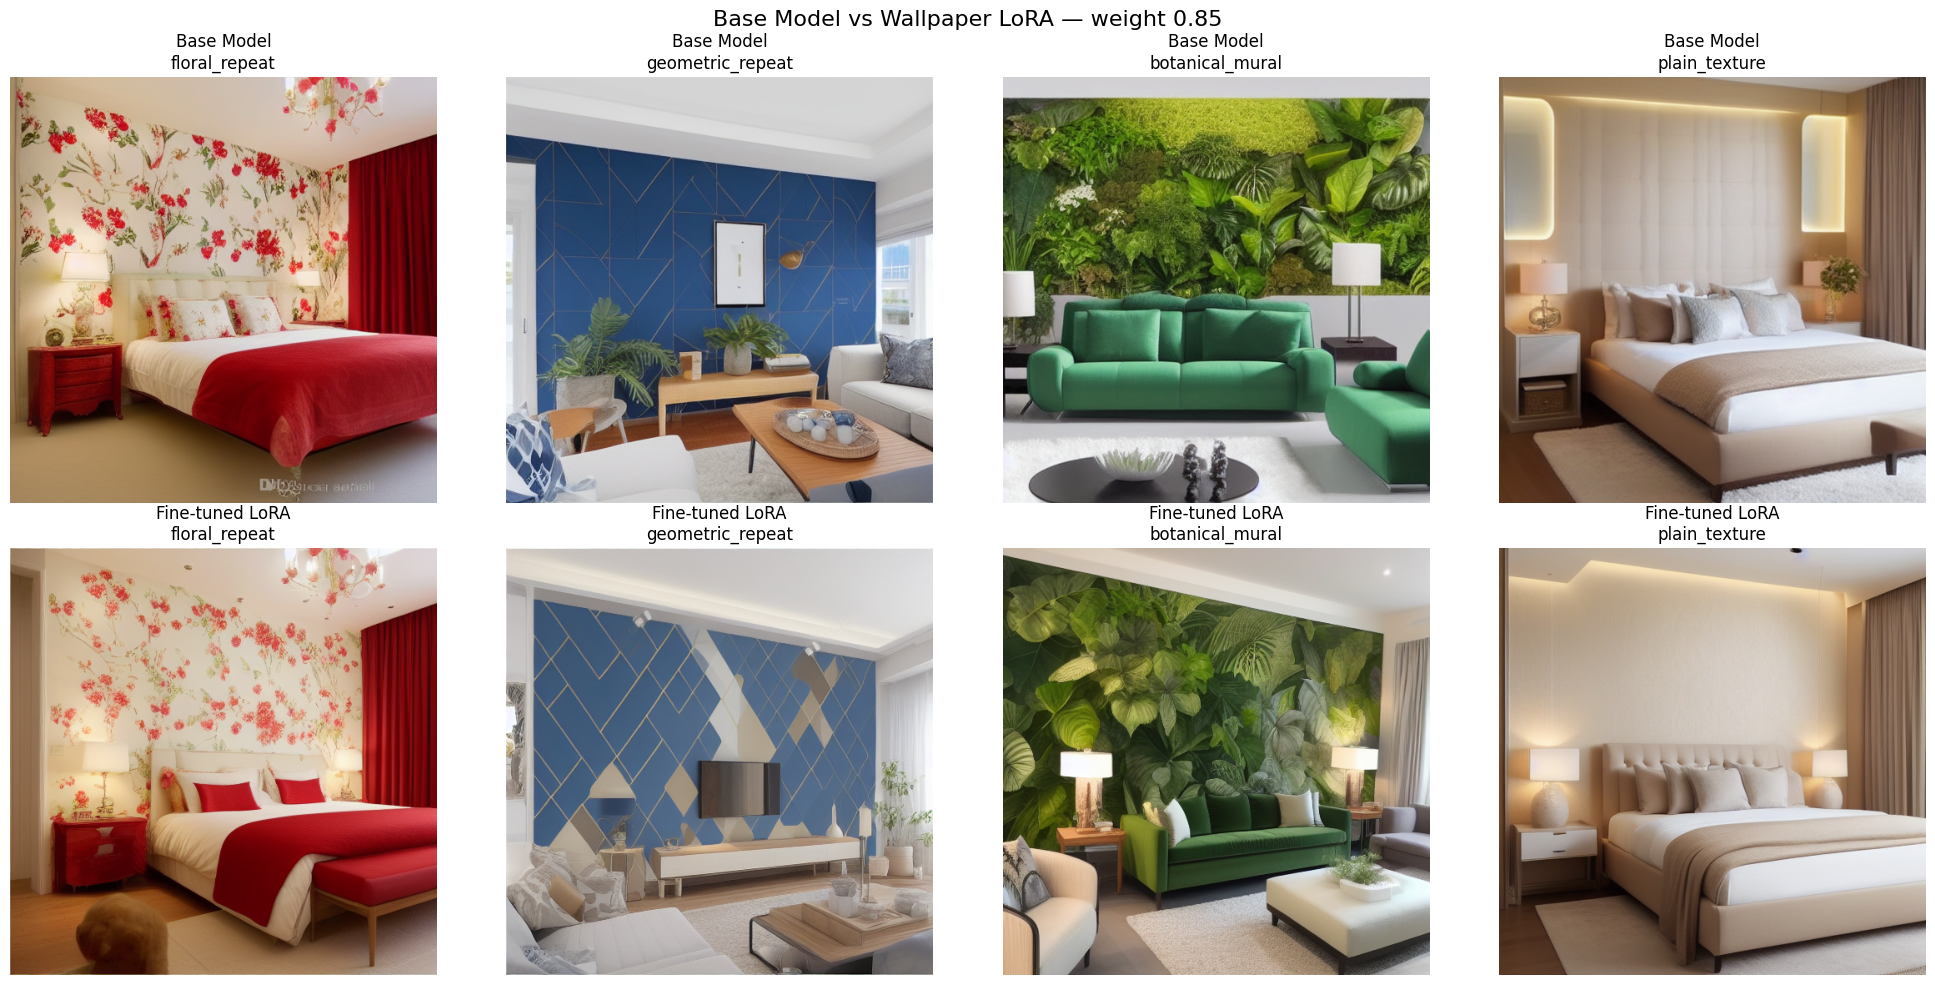

,prompt_name,seed,base_image,lora_image,lora_weight
0,floral_repeat,42,/kaggle/working/wallpaper_lora_project/preview...,/kaggle/working/wallpaper_lora_project/preview...,0.85
1,geometric_repeat,43,/kaggle/working/wallpaper_lora_project/preview...,/kaggle/working/wallpaper_lora_project/preview...,0.85
2,botanical_mural,44,/kaggle/working/wallpaper_lora_project/preview...,/kaggle/working/wallpaper_lora_project/preview...,0.85
3,plain_texture,45,/kaggle/working/wallpaper_lora_project/preview...,/kaggle/working/wallpaper_lora_project/preview...,0.85


Saved visual comparison: /kaggle/working/wallpaper_lora_project/previews/evaluation/base_vs_final_lora.png


In [19]:

EVAL_PROMPTS = [
    (
        "floral_repeat",
        "wallpapx, photorealistic bedroom interior, feature wall covered with "
        "small-scale floral repeating wallpaper, warm cream background, "
        "delicate red and green botanical motifs, matte finish, realistic pattern scale"
    ),
    (
        "geometric_repeat",
        "wallpapx, photorealistic modern living room, feature wall covered with "
        "blue and beige geometric repeating wallpaper, clean angular motifs, "
        "matte paper finish, realistic pattern scale"
    ),
    (
        "botanical_mural",
        "wallpapx, photorealistic living room, feature wall covered with an "
        "oversized botanical wall mural, continuous muted green leaf composition, "
        "matte finish, correct wall perspective"
    ),
    (
        "plain_texture",
        "wallpapx, photorealistic elegant bedroom, feature wall covered with "
        "subtle warm beige plain textured wallpaper, fine textile-like surface, "
        "matte finish"
    ),
]

NEGATIVE_PROMPT = (
    "floor wallpaper, floor tiles, carpet, rug, wallpaper on furniture, "
    "deformed room, warped wall, distorted pattern, broken repetition, "
    "melted texture, blurry, low resolution, artifacts, text, logo, watermark"
)

def generate_prompt_set(pipeline, prompts, output_prefix):
    generated = []
    for index, (prompt_name, prompt) in enumerate(prompts):
        seed = SEED + index
        generator = torch.Generator(device="cuda").manual_seed(seed)

        image = pipeline(
            prompt=prompt,
            negative_prompt=NEGATIVE_PROMPT,
            num_inference_steps=30,
            guidance_scale=7.0,
            width=512,
            height=512,
            generator=generator,
        ).images[0]

        output_path = EVAL_DIR / f"{output_prefix}__{prompt_name}.png"
        image.save(output_path)
        generated.append({
            "prompt_name": prompt_name,
            "prompt": prompt,
            "seed": seed,
            "image": image,
            "path": str(output_path),
        })
    return generated

BASE_EVAL_PROMPTS = [
    (
        prompt_name,
        re.sub(
            rf"^{re.escape(TRIGGER_TOKEN)}\s*,\s*",
            "",
            prompt,
            flags=re.IGNORECASE,
        ),
    )
    for prompt_name, prompt in EVAL_PROMPTS
]

base_results = generate_prompt_set(
    pipe,
    BASE_EVAL_PROMPTS,
    "base_model",
)

adapter_name = "wallpaper_final"
pipe.load_lora_weights(
    str(FINAL_LORA.parent),
    weight_name=FINAL_LORA.name,
    adapter_name=adapter_name,
)
pipe.set_adapters(
    [adapter_name],
    adapter_weights=[LORA_TEST_WEIGHT],
)

lora_results = generate_prompt_set(
    pipe,
    EVAL_PROMPTS,
    "final_lora",
)

fig, axes = plt.subplots(
    2,
    len(EVAL_PROMPTS),
    figsize=(5 * len(EVAL_PROMPTS), 10),
)

for column, result in enumerate(base_results):
    axes[0, column].imshow(result["image"])
    axes[0, column].set_title(f"Base Model\n{result['prompt_name']}")
    axes[0, column].axis("off")

for column, result in enumerate(lora_results):
    axes[1, column].imshow(result["image"])
    axes[1, column].set_title(f"Fine-tuned LoRA\n{result['prompt_name']}")
    axes[1, column].axis("off")

plt.suptitle(
    f"Base Model vs Wallpaper LoRA — weight {LORA_TEST_WEIGHT}",
    fontsize=16,
)
plt.tight_layout()

comparison_path = EVAL_DIR / "base_vs_final_lora.png"
plt.savefig(comparison_path, dpi=180, bbox_inches="tight")
plt.show()

comparison_records = []
for base_item, lora_item in zip(base_results, lora_results):
    comparison_records.append({
        "prompt_name": base_item["prompt_name"],
        "seed": base_item["seed"],
        "base_image": base_item["path"],
        "lora_image": lora_item["path"],
        "lora_weight": LORA_TEST_WEIGHT,
    })

comparison_df = pd.DataFrame(comparison_records)
comparison_df.to_csv(EVAL_DIR / "base_vs_lora.csv", index=False)
display(comparison_df)

try:
    pipe.delete_adapters(adapter_name)
except Exception:
    pipe.unload_lora_weights()

cleanup_memory()
print("Saved visual comparison:", comparison_path)


In [ ]:

def checkpoint_epoch(path: Path):
    match = re.search(r"-(\d+)\.safetensors$", path.name)
    return int(match.group(1)) if match else None

epoch_checkpoints = [
    path for path in OUTPUT_DIR.glob("wallpaper_lora-*.safetensors")
    if checkpoint_epoch(path) is not None
]
epoch_checkpoints = sorted(epoch_checkpoints, key=checkpoint_epoch)

if RUN_CHECKPOINT_EVOLUTION and epoch_checkpoints:
    evolution_prompts = [
        EVAL_PROMPTS[0],  
        EVAL_PROMPTS[2],  
    ]

    evolution_rows = []

    for checkpoint_index, checkpoint_path in enumerate(epoch_checkpoints):
        adapter_name = f"epoch_{checkpoint_epoch(checkpoint_path)}"
        print("Evaluating:", checkpoint_path.name)

        pipe.load_lora_weights(
            str(checkpoint_path.parent),
            weight_name=checkpoint_path.name,
            adapter_name=adapter_name,
        )
        pipe.set_adapters(
            [adapter_name],
            adapter_weights=[LORA_TEST_WEIGHT],
        )

        generated = generate_prompt_set(
            pipe,
            evolution_prompts,
            checkpoint_path.stem,
        )

        for item in generated:
            evolution_rows.append({
                "checkpoint": checkpoint_path.name,
                "epoch": checkpoint_epoch(checkpoint_path),
                "prompt_name": item["prompt_name"],
                "seed": item["seed"],
                "image_path": item["path"],
                "image": item["image"],
            })

        try:
            pipe.delete_adapters(adapter_name)
        except Exception:
            pipe.unload_lora_weights()

        cleanup_memory()

    evolution_df = pd.DataFrame(evolution_rows)

    prompt_names = [name for name, _ in evolution_prompts]
    fig, axes = plt.subplots(
        len(prompt_names),
        len(epoch_checkpoints),
        figsize=(5 * len(epoch_checkpoints), 5 * len(prompt_names)),
    )

    if len(prompt_names) == 1:
        axes = np.expand_dims(axes, axis=0)
    if len(epoch_checkpoints) == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_index, prompt_name in enumerate(prompt_names):
        subset = evolution_df[
            evolution_df["prompt_name"] == prompt_name
        ].sort_values("epoch")

        for column_index, record in enumerate(subset.itertuples(index=False)):
            axes[row_index, column_index].imshow(record.image)
            axes[row_index, column_index].set_title(
                f"{prompt_name}\nEpoch {record.epoch}"
            )
            axes[row_index, column_index].axis("off")

    plt.suptitle("Wallpaper LoRA — Checkpoint Evolution", fontsize=16)
    plt.tight_layout()

    evolution_grid_path = EVAL_DIR / "checkpoint_evolution.png"
    plt.savefig(evolution_grid_path, dpi=180, bbox_inches="tight")
    plt.show()

    evolution_df.drop(columns=["image"]).to_csv(
        EVAL_DIR / "checkpoint_evolution.csv",
        index=False,
    )
    print("Saved:", evolution_grid_path)
else:
    print("Checkpoint evolution skipped or no epoch checkpoints found.")

del pipe
cleanup_memory()


Evaluating: wallpaper_lora-000002.safetensors


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Evaluating: wallpaper_lora-000004.safetensors


  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Evaluating: wallpaper_lora-000008.safetensors


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

In [21]:

final_summary = pd.DataFrame([
    {"Item": "Training images", "Value": len(manifest)},
    {"Item": "Trigger token", "Value": TRIGGER_TOKEN},
    {"Item": "Base model", "Value": str(BASE_MODEL)},
    {"Item": "Resolution", "Value": f"{RESOLUTION}px with aspect-ratio bucketing"},
    {"Item": "LoRA rank / alpha", "Value": f"{NETWORK_DIM} / {NETWORK_ALPHA}"},
    {"Item": "Training epochs", "Value": MAX_TRAIN_EPOCHS},
    {"Item": "Estimated steps", "Value": estimated_steps},
    {"Item": "Optimizer", "Value": "AdamW8bit"},
    {"Item": "Learning rate", "Value": LEARNING_RATE},
    {"Item": "Mixed precision", "Value": "fp16"},
    {"Item": "Final LoRA", "Value": str(FINAL_LORA)},
    {"Item": "Visual comparison", "Value": str(comparison_path)},
])
display(final_summary)

run_info = {
    row["Item"]: row["Value"]
    for row in final_summary.to_dict(orient="records")
}
run_info["gpu"] = gpu_name
run_info["vram_gb"] = vram_gb
run_info["torch_version"] = torch.__version__

run_info_path = WORK_ROOT / "run_info.json"
run_info_path.write_text(
    json.dumps(run_info, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("العناصر الأساسية للعرض:")
print("1. dataset_samples.png")
print("2. training_loss.png")
print("3. base_vs_final_lora.png")
print("4. checkpoint_evolution.png")
print("5. ملفات LoRA داخل output/")


,Item,Value
0,Training images,206
1,Trigger token,wallpapx
2,Base model,stable-diffusion-v1-5/stable-diffusion-v1-5
3,Resolution,512px with aspect-ratio bucketing
4,LoRA rank / alpha,32 / 16
5,Training epochs,10
6,Estimated steps,2060
7,Optimizer,AdamW8bit
8,Learning rate,0.0001
9,Mixed precision,fp16


العناصر الأساسية للعرض:
1. dataset_samples.png
2. training_loss.png
3. base_vs_final_lora.png
4. checkpoint_evolution.png
5. ملفات LoRA داخل output/
